In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("/content/accident_dataset_multiclass.csv")
df.head()

,peak_acc,mean_acc,std_acc,acc_range,jerk_mean,gyro_mean,gyro_std,gyro_range,energy_acc,energy_gyro,label
0,8.173440,11.031621,0.930278,3.813510,0.755535,0.209244,0.143726,0.879827,919.655478,55.774533,0
1,10.560312,10.190911,0.733100,3.232050,0.633935,0.220310,0.186364,0.654851,949.245126,29.299152,0
2,30.858439,15.864526,3.827198,14.141178,7.043104,4.101197,1.594500,6.009703,5787.024685,817.555851,3
3,19.187411,8.846610,2.416764,3.396039,2.851107,0.759265,0.332580,1.703363,1955.062179,115.238430,1
4,35.019732,14.220153,3.121677,15.896481,5.382265,3.183260,2.365690,6.049268,4755.619737,962.221998,3


In [ ]:
df["label"].value_counts()

,count
label,
0,100
3,100
1,100
2,100


In [ ]:
df["label"] = df["label"].apply(lambda x: 1 if x == 3 else 0)
df["label"].value_counts()

,count
label,
0,300
1,100


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 1 0
 0 0 0 1 1 0]


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[60  0]
 [ 0 20]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        20

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



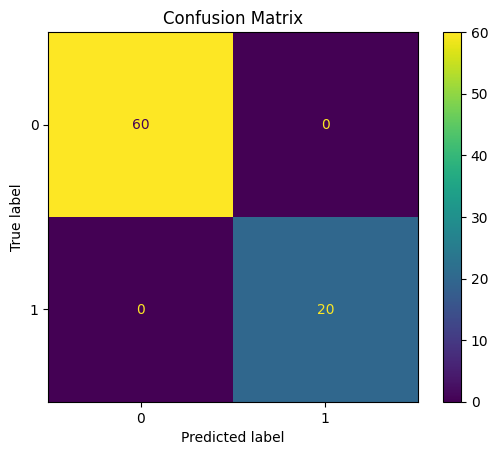

In [ ]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

y_prob[:10]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 1.])

In [ ]:
import joblib
joblib.dump(model, "rf_accident_model.pkl")

['rf_accident_model.pkl']